In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/cleaned_retail.csv', parse_dates=['InvoiceDate'])

print("Shape:", df.shape)
df.head()

Shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)


rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print("\nRFM Shape:", rfm.shape)
print("\nSample RFM:")
rfm.head()

Snapshot date: 2010-12-10 20:01:00

RFM Shape: (4312, 4)

Sample RFM:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [4]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

print("Scaling done!")
print("Shape:", rfm_scaled.shape)

Scaling done!
Shape: (4312, 3)


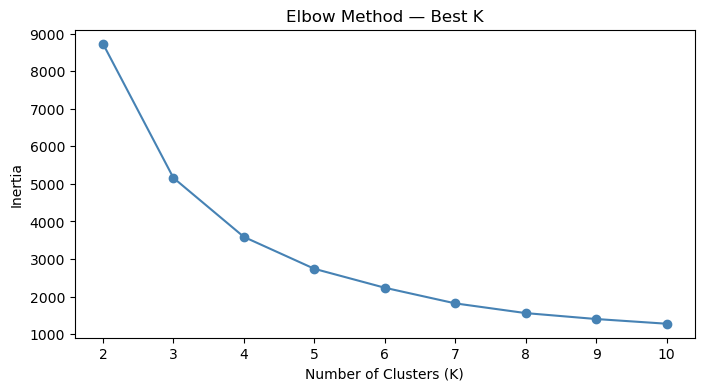

Done!


In [5]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,11), inertias, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Best K')
plt.savefig('visuals/elbow.png', bbox_inches='tight')
plt.show()
print("Done!")

In [6]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Segment'] = km.fit_predict(rfm_scaled)


print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

         Recency  Frequency   Monetary
Segment                               
0          42.26       4.94    2082.32
1         241.68       1.65     594.02
2           4.23     111.54  112132.39


In [7]:
segment_names = {
    0: 'Regular Customers',
    1: 'Lost Customers', 
    2: 'Champions'
}

rfm['Segment_Name'] = rfm['Segment'].map(segment_names)

print(rfm['Segment_Name'].value_counts())

Segment_Name
Regular Customers    3239
Lost Customers       1060
Champions              13
Name: count, dtype: int64


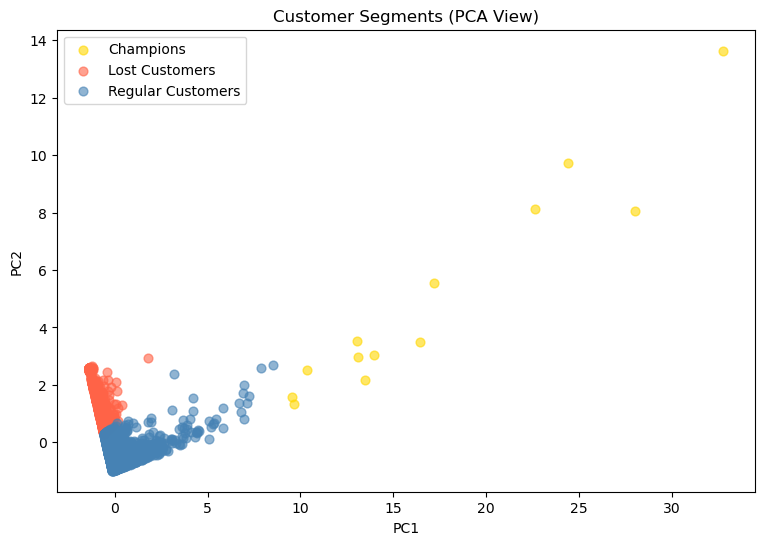

Done!


In [8]:

pca = PCA(n_components=2)
coords = pca.fit_transform(rfm_scaled)
rfm['PC1'] = coords[:, 0]
rfm['PC2'] = coords[:, 1]

plt.figure(figsize=(9,6))
colors = {'Champions':'gold', 'Regular Customers':'steelblue', 'Lost Customers':'tomato'}
for seg, grp in rfm.groupby('Segment_Name'):
    plt.scatter(grp['PC1'], grp['PC2'], 
                label=seg, color=colors[seg], alpha=0.6, s=40)

plt.title('Customer Segments (PCA View)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.savefig('visuals/segments.png', bbox_inches='tight')
plt.show()
print("Done!")

In [9]:
rfm.to_csv('data/rfm_segments.csv', index=False)
print("Saved!")

Saved!


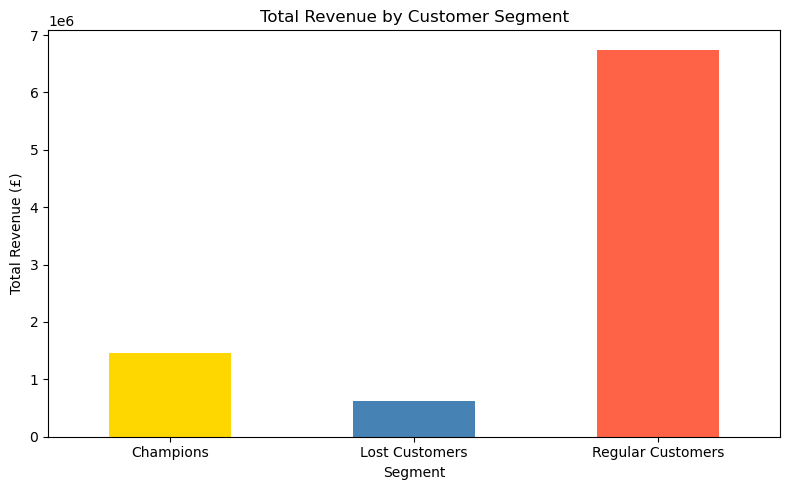

Chart 4 saved!


In [10]:
segment_revenue = rfm.groupby('Segment_Name')['Monetary'].sum()

plt.figure(figsize=(8,5))
colors = ['gold', 'steelblue', 'tomato']
segment_revenue.plot(kind='bar', color=colors)
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visuals/revenue_by_segment.png', bbox_inches='tight')
plt.show()
print("Chart 4 saved!")